In [1]:
# Execute this cell
import numpy as np
from scipy import stats
import scipy
import matplotlib.pyplot as plt
import pandas as pd
#%matplotlib inline
#%config InlineBackend.figure_format='retina'

from scipy import integrate
from scipy.stats import norm

# Tasks

Let's go back to our previous example on the astrophysical transient.


8) Fit the same model from before with the same priors,  but this time use nested sampling.

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

Be careful with how you transform your parameter space into a unit hypercube for the nested sampling priors (I used `ppf` from `scipy.stats.uniform`, but there are other ways to do it)

An appropriate check on whether you have done things correctly is that the posterior samples you get from the burst analysis here should give an equivalent corner plot to the MCMC you did earlier.

7) Another possible model that may explain the data is a Gaussian profile described by:

$y = b + A\exp[-(t-t_0)^2 / 2\sigma_W^2]$

Fit this model using nested sampling and reasonable priors (this time is up to you to decide...)

9) Unlike MCMCs, nested sampling provides the Bayesian evidence. Compute the Bayesian evidence for this Gaussian model, and for the original burst model. Which model is the favored description of the data? Express this in terms of the Jeffrey's scale.

### Data and model inspection

In [2]:
data = np.load("../solutions/transient.npy")

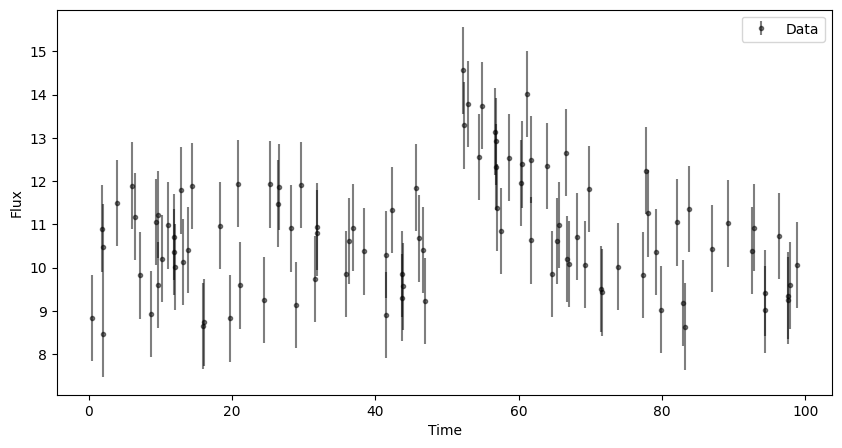

In [3]:
t, y, y_err = data[:, 0], data[:, 1], data[:, 2]


plt.figure(figsize=(10, 5))
plt.errorbar(t, y, yerr=y_err, fmt='.k', capsize=0, alpha=0.5, label='Data')
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()

In [8]:
def burst_model(theta, t):
    b, A, t0, alpha = theta
    model = np.full_like(t, b)  # Costant background b
    mask = (t >= t0)
    model[mask] += A * np.exp(-(t[mask] - t0) *alpha)
    return model

def gaussian_model(theta, t):
    b, A, t0, sigma = theta
    model = b + A * np.exp(-(t-t0)**2/(2*sigma**2))
    return model
    

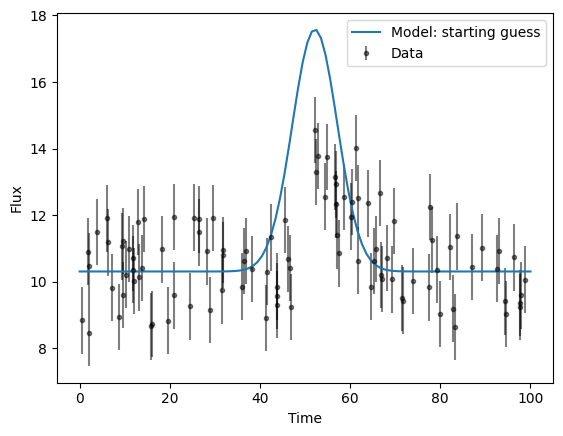

In [5]:
t_ax = np.linspace(0,100,100)
initial_guess = [np.mean(y[:10]), np.max(y)/2, t[np.argmax(y)], 5] #possible parameters
y_ax = gaussian_model(initial_guess, t_ax)
plt.errorbar(t, y, yerr=y_err, fmt='.k', capsize=0, alpha=0.5, label='Data')
plt.plot(t_ax,y_ax,label='Model: starting guess')
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()

### Nested sampling through dynesty

In [6]:
import dynesty

In [7]:
ndim = 4

def log_likelihood(theta, data, model):
    x, y, sigma_y = data.T
    if model =='burst_model':
        y_fit = burst_model(theta, x)
    elif model == 'gaussian_model':
        y_fit = gaussian_model(theta, x)

    return -0.5 * np.sum((y-y_fit)**2 / sigma_y**2 ) 


def ptform(u,model):
    """Transforms the uniform random variables `u ~ Unif[0., 1.)`
    to the parameters of interest."""

    x = np.array(u)  #ausiliar vector

    x[0] = scipy.stats.uniform(loc=0,scale=50).ppf(u[0]) #b
    x[1] = scipy.stats.uniform(loc=0,scale=50).ppf(u[1]) #A
    x[2] = scipy.stats.uniform(loc=0,scale=100).ppf(u[2]) #t0
   
    if model =='burst_model':
        x[3] = scipy.stats.loguniform.ppf(u[3],np.exp(-5),np.exp(5)) #alpha
    elif model =='gaussian_model':
        x[3] = scipy.stats.loguniform.ppf(u[3],np.exp(-3),np.exp(3)) #sigma

    return x

### Burst model

In [11]:
# "Static" nested sampling.
sampler = dynesty.NestedSampler(log_likelihood, ptform, ndim, logl_args=[data, 'burst_model'], ptform_args=['burst_model'], nlive=400)
#sampler.run_nested()
#sresults = sampler.results

In [12]:
sampler.run_nested()
sresults = sampler.results

iter: 2617 | bound: 35 | nc: 15 | ncall: 29187 | eff(%):  8.966 | loglstar:   -inf < -87.364 <    inf | logz: -94.074 +/-  0.122 | dlogz: 36.373 >  0.409                                             c:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\dynesty\bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
iter: 6184 | +400 | bound: 235 | nc: 1 | ncall: 136502 | eff(%):  4.838 | loglstar:   -inf < -48.775 <    inf | logz: -63.225 +/-  0.185 | dlogz:  0.001 >  0.409                                     

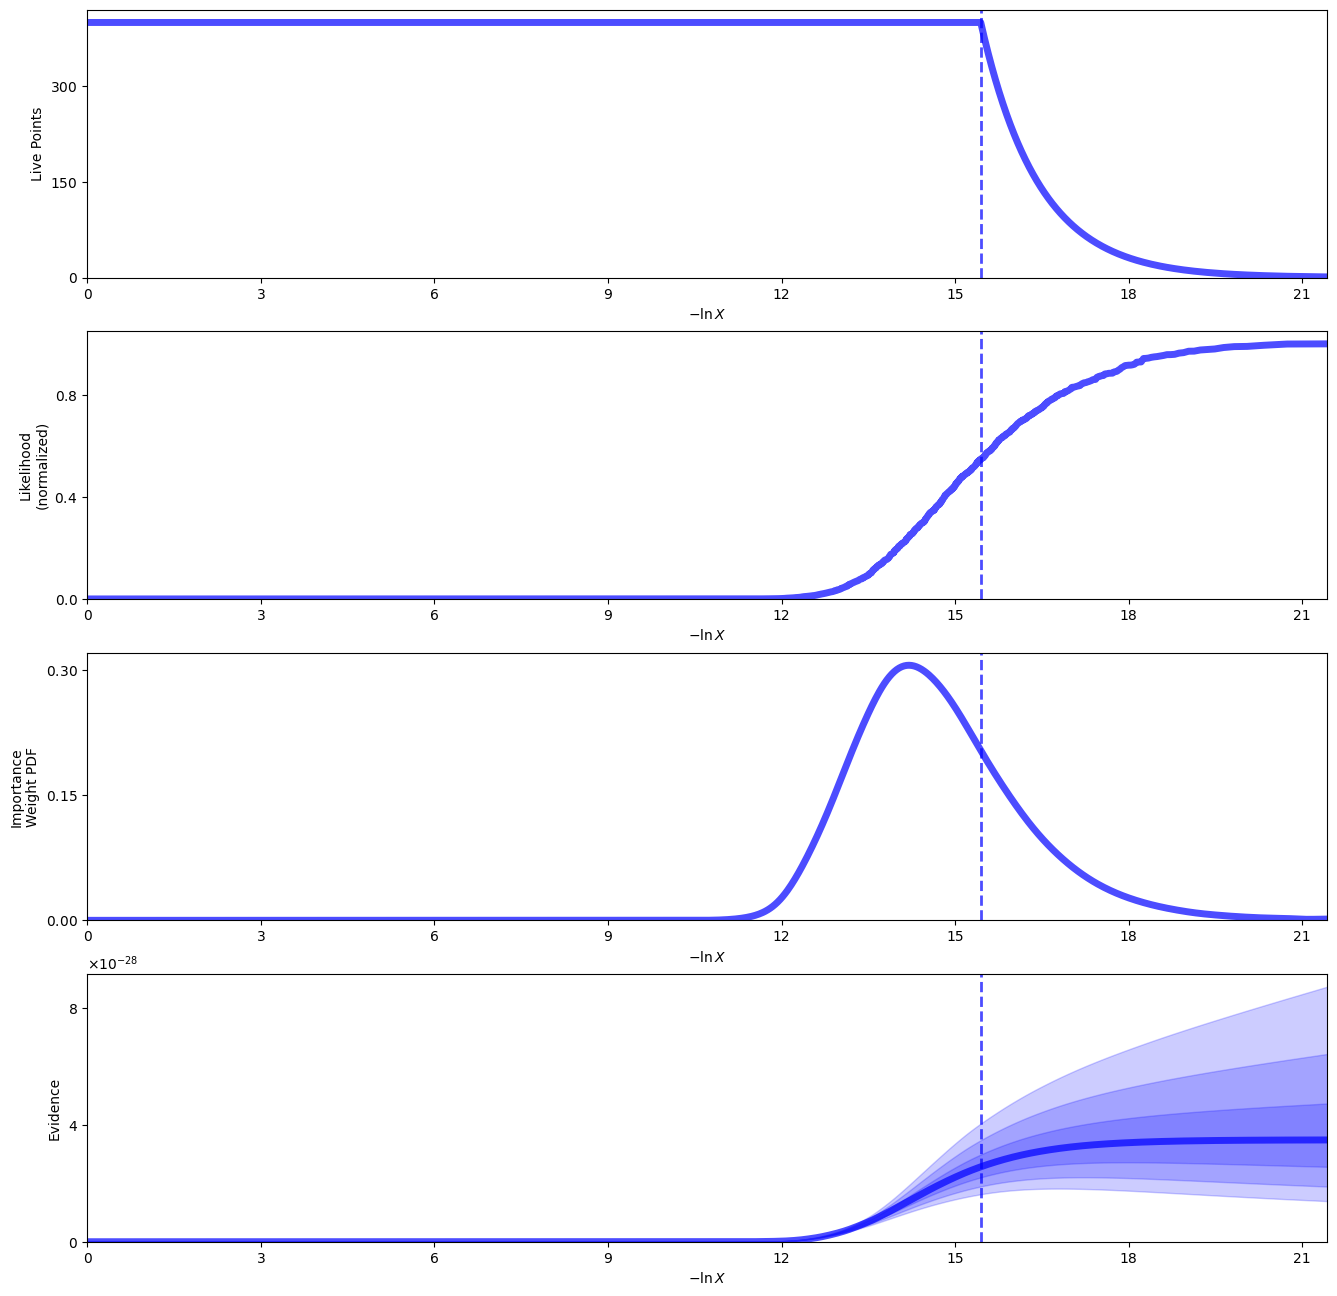

In [13]:
from dynesty import plotting as dyplot

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(sresults)

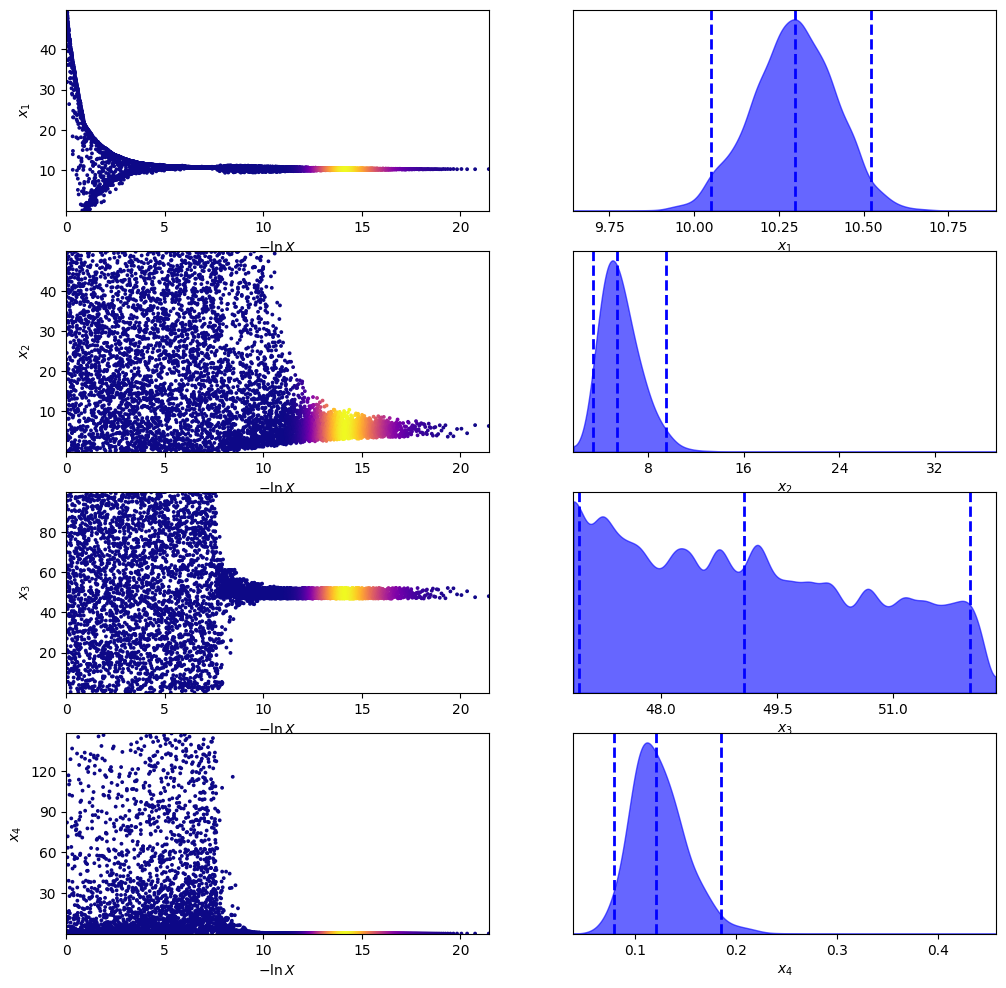

In [14]:
tfig, taxes = dyplot.traceplot(sresults)

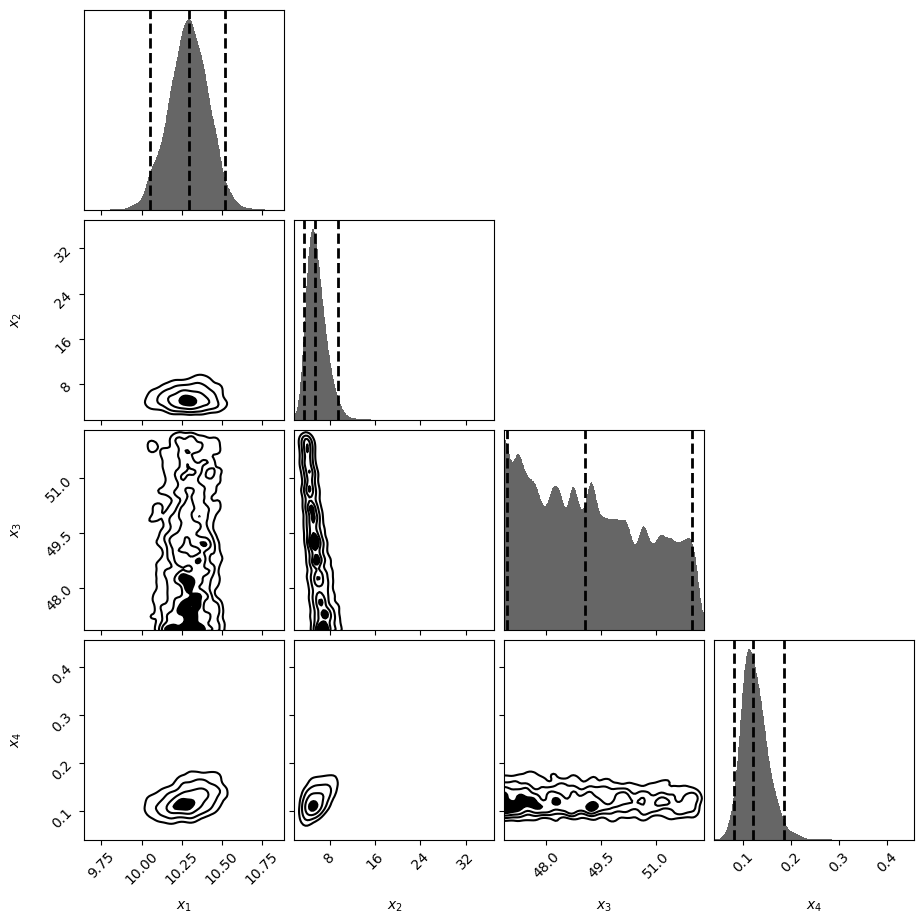

In [15]:
cfig, caxes = dyplot.cornerplot(sresults)

In [16]:
from dynesty import utils as dyfunc


# Extract sampling results.
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights


evidence = sresults.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence))

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))

# Generate a new set of results with statistical+sampling uncertainties.
#results_sim = dyfunc.simulate_run(sresults)

Bayesian evidence 3.479708277721969e-28
68% parameter credible regions are:
 [[10.173194016635984, 10.411972041118156], [4.191710550277576, 7.266872466046435], [47.45757938474576, 51.06029330018825], [0.09923692531481759, 0.14963186847738885]]

Mean and covariance of parameters are: [10.29279777  5.71773589 49.19150742  0.12429993]
[[ 1.48483486e-02  1.41409195e-02 -5.87445730e-03  1.29782792e-03]
 [ 1.41409195e-02  2.60582814e+00 -1.67328595e+00  2.56532725e-02]
 [-5.87445730e-03 -1.67328595e+00  2.33348138e+00 -1.62825327e-03]
 [ 1.29782792e-03  2.56532725e-02 -1.62825327e-03  7.40803089e-04]]


In [17]:
quantiles = [dyfunc.quantile(samps, [0.05, 0.5, 0.95], weights=weights)
             for samps in samples.T]
for q,l in zip(quantiles,['b', 'A', 't0', 'alpha']):
    low,med,up=q
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

b   10.296675842350789 +0.18639500979191226 -0.21617864663788033
A   5.43761944144236 +3.3084048864182343 -1.7811594413136227
t0   49.07078235879437 +2.7616466882075343 -2.0416738937009242
alpha   0.12070787052996987 +0.0528970428222425 -0.034745751374665124


In [18]:

sresults.summary()

Summary
nlive: 400
niter: 6184
ncall: 136102
eff(%):  4.838
logz: -63.225 +/-  0.306


In [19]:
# Resample weighted samples.
samples_equal = dyfunc.resample_equal(samples, weights)

C:\Users\annat\AppData\Roaming\Python\Python311\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


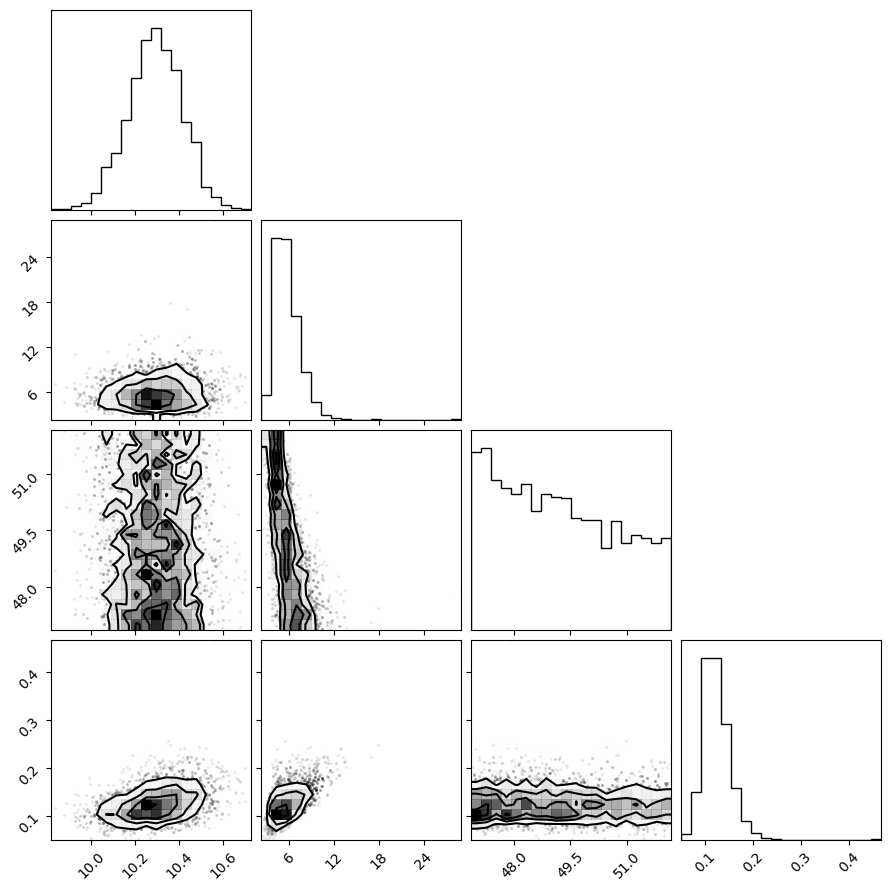

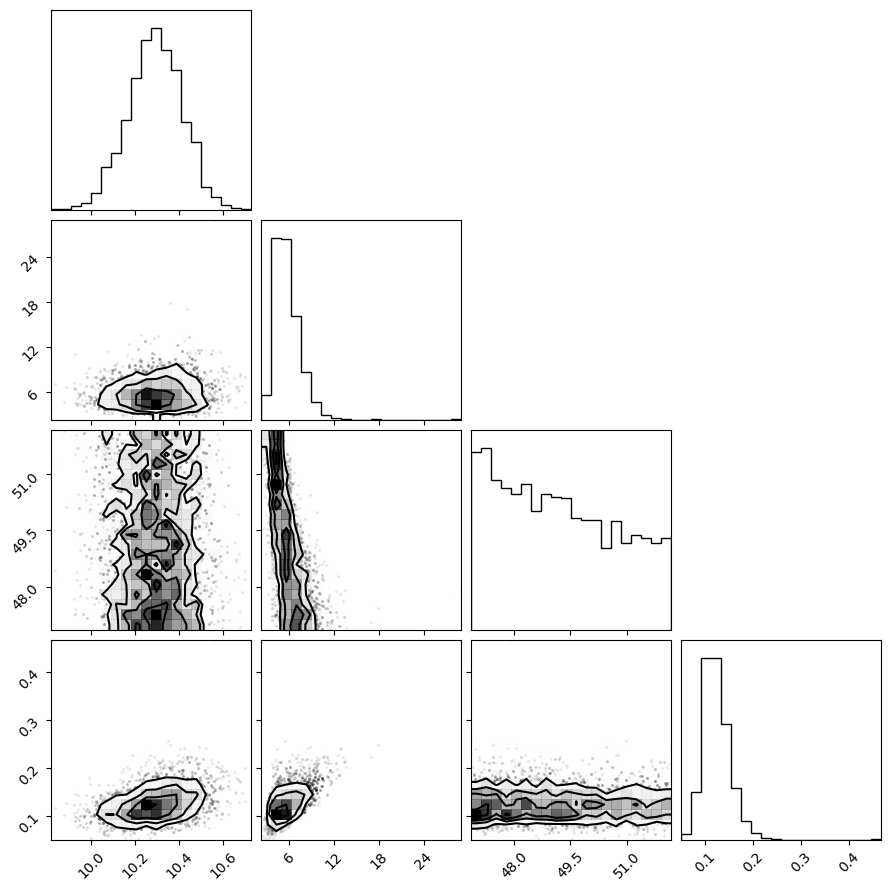

In [20]:
import corner
corner.corner(samples_equal)

In [21]:
samples_equal

array([[10.19497784,  8.10690558, 47.16899303,  0.11409029],
       [10.36919185,  5.8325283 , 48.21450539,  0.13351095],
       [10.12424598,  4.69448691, 51.15154832,  0.11632769],
       ...,
       [10.2249203 ,  4.32754421, 49.16340333,  0.1012783 ],
       [10.28018805,  5.73300681, 47.80333654,  0.09823211],
       [10.35404895,  9.90203355, 47.54446112,  0.17685103]],
      shape=(6584, 4))

### Gaussian model

In [22]:
# "Static" nested sampling.
sampler2 = dynesty.NestedSampler(log_likelihood, ptform, ndim, logl_args=[data, 'gaussian_model'], ptform_args=['gaussian_model'], nlive=400) #sample='rslice', nlive=1000)
#sampler.run_nested()
#sresults = sampler.results

In [23]:
sampler2.run_nested()
sresults2 = sampler2.results

iter: 3308 | bound: 78 | nc: 320 | ncall: 48731 | eff(%):  6.788 | loglstar:   -inf < -86.508 <    inf | logz: -93.978 +/-  0.126 | dlogz: 31.851 >  0.409                                            c:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\dynesty\bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
iter: 3584 | bound: 116 | nc: 233 | ncall: 68354 | eff(%):  5.243 | loglstar:   -inf < -80.959 <    inf | logz: -91.750 +/-  0.151 | dlogz: 28.949 >  0.409                                           c:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\dynesty\bounding.py:707: UserWarning: The enlargement factor for 

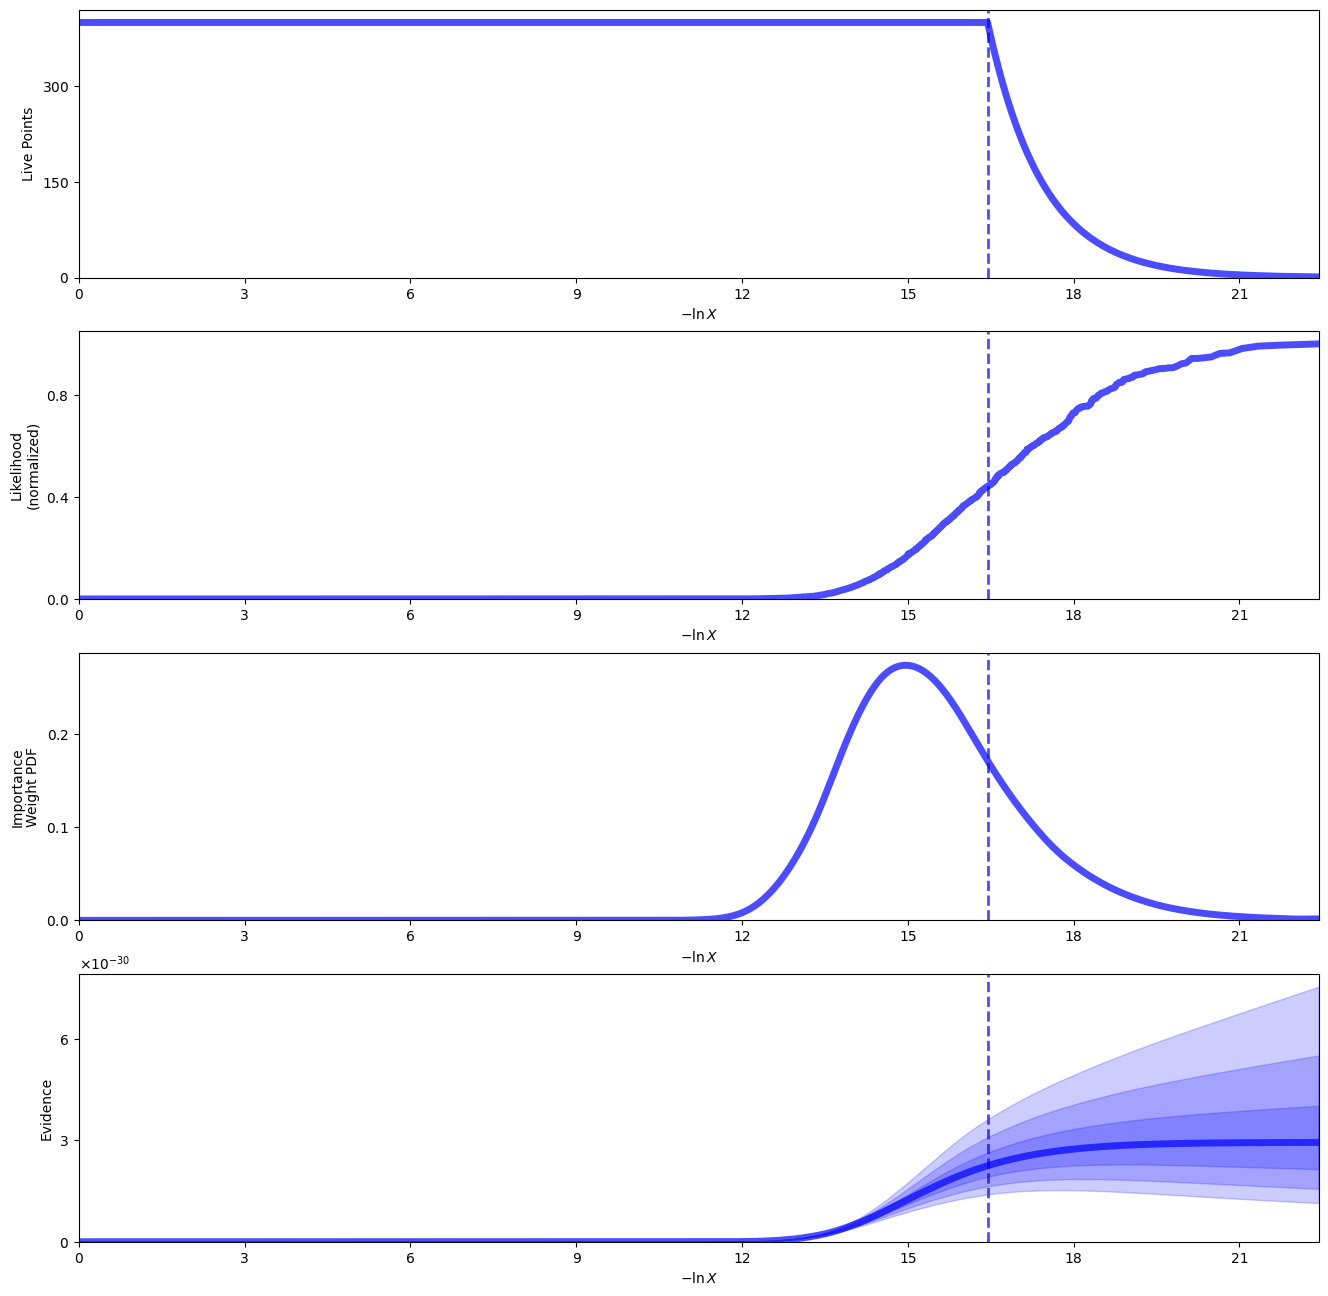

In [24]:

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(sresults2)

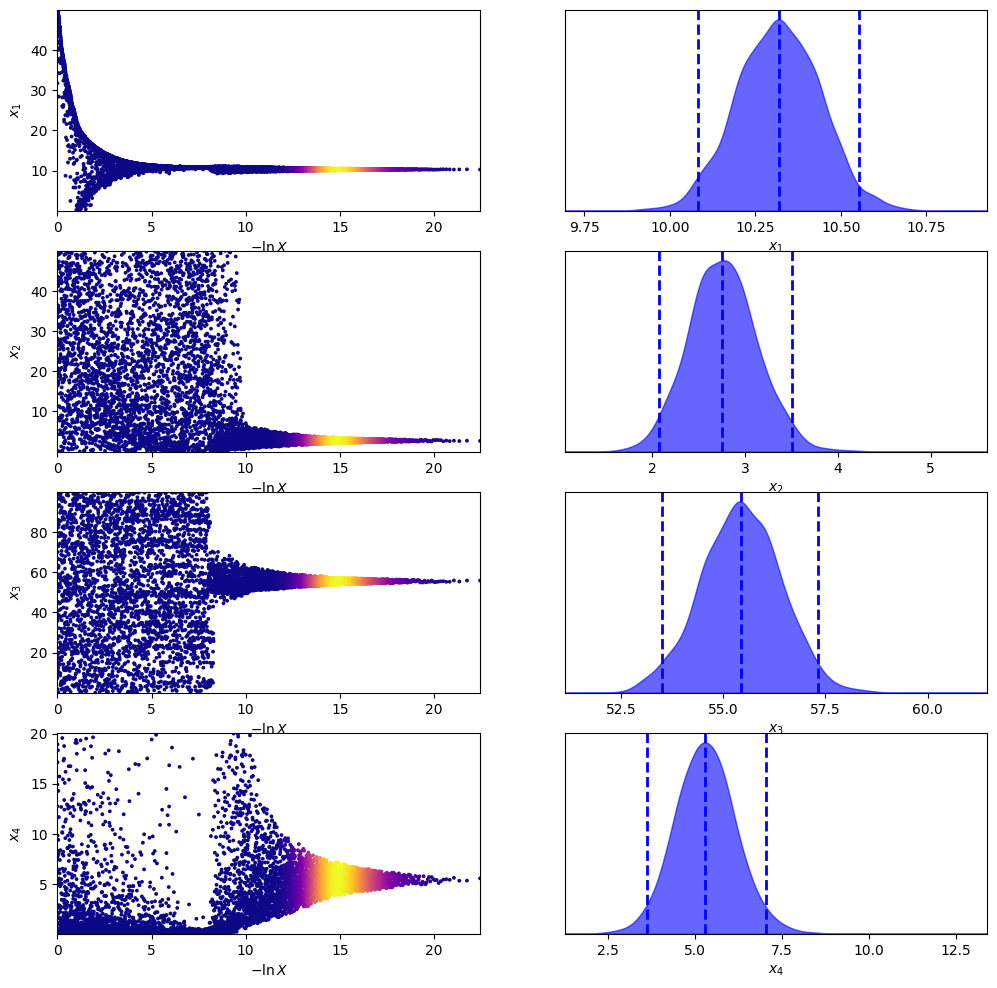

In [25]:
tfig, taxes = dyplot.traceplot(sresults2)

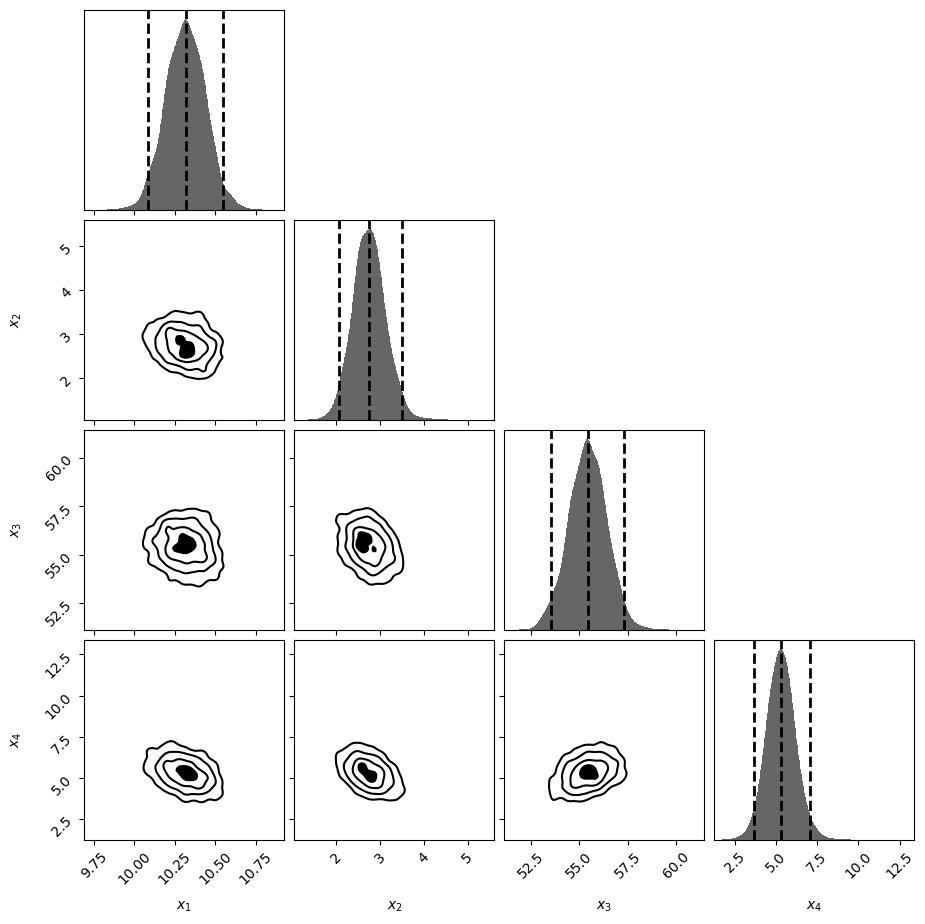

In [26]:
cfig, caxes = dyplot.cornerplot(sresults2)

In [27]:
# Extract sampling results.
samples2 = sresults2.samples  # samples
weights2 = np.exp(sresults2.logwt - sresults2.logz[-1])  # normalized weights


evidence2 = sresults2.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence2))

# Compute 10%-90% quantiles.
quantiles2 = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights2)
             for samps in samples2.T]
print('68% parameter credible regions are:\n ' + str(quantiles2) + '\n')

# Compute weighted mean and covariance.
mean2, cov2 = dyfunc.mean_and_cov(samples2, weights2)
print('Mean and covariance of parameters are: ' + str(mean2) + '\n' + str(cov2))

# Generate a new set of results with statistical+sampling uncertainties.
#results_sim = dyfunc.simulate_run(sresults)

Bayesian evidence 2.936373345344513e-30
68% parameter credible regions are:
 [[10.198866676075518, 10.436366253078738], [2.408148150162373, 3.1183357850498026], [54.50261434113055, 56.38702190808466], [4.478831505653039, 6.1166310246715385]]

Mean and covariance of parameters are: [10.31745545  2.76065628 55.43543334  5.30571875]
[[ 0.01450745 -0.00836851 -0.01896374 -0.03914255]
 [-0.00836851  0.1358656  -0.12094479 -0.14001797]
 [-0.01896374 -0.12094479  0.93900051  0.29349075]
 [-0.03914255 -0.14001797  0.29349075  0.74571986]]


In [28]:
quantiles2 = [dyfunc.quantile(samps, [0.05, 0.5, 0.95], weights=weights2)
             for samps in samples2.T]
for q,l in zip(quantiles2,['b', 'A', 't0', 'sigma']):
    low,med,up=q
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

b   10.318316254053343 +0.19115043429482448 -0.20363509756773013
A   2.753245533812471 +0.6333699558898056 -0.5920872164044955
t0   55.43477816092576 +1.5721824694800972 -1.6401846880670732
sigma   5.294310558642417 +1.4553603417108878 -1.353756672649931


In [29]:

sresults2.summary()

Summary
nlive: 400
niter: 6585
ncall: 135498
eff(%):  5.155
logz: -68.000 +/-  0.315


In [30]:
# Resample weighted samples.
samples_equal2 = dyfunc.resample_equal(samples2, weights2)

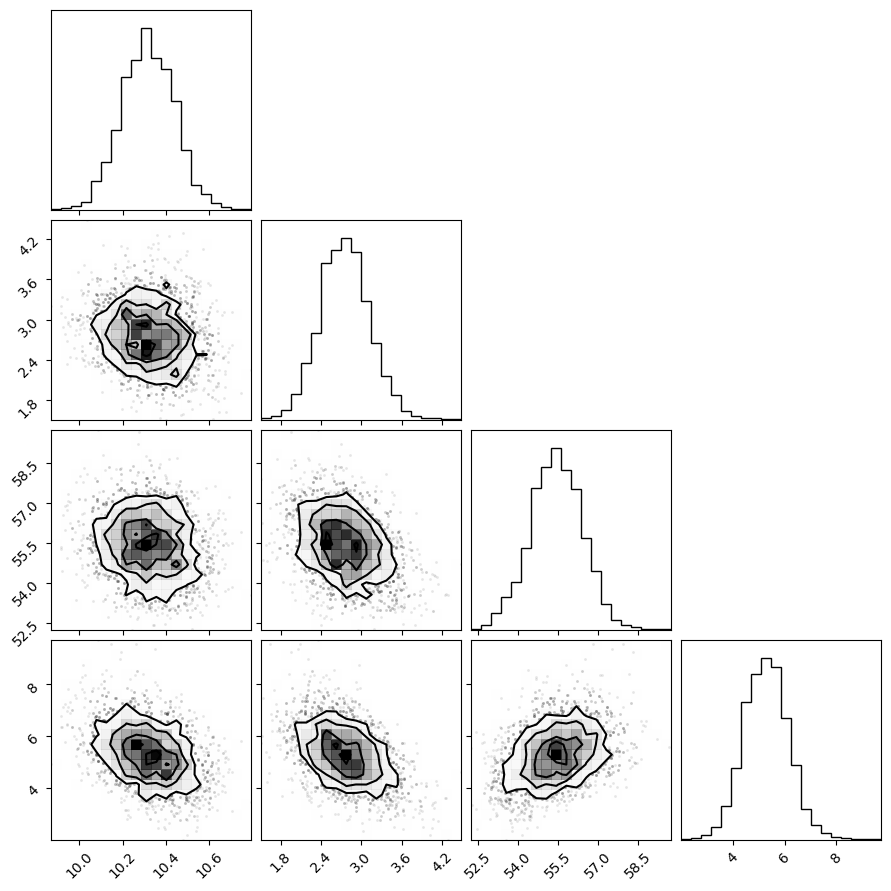

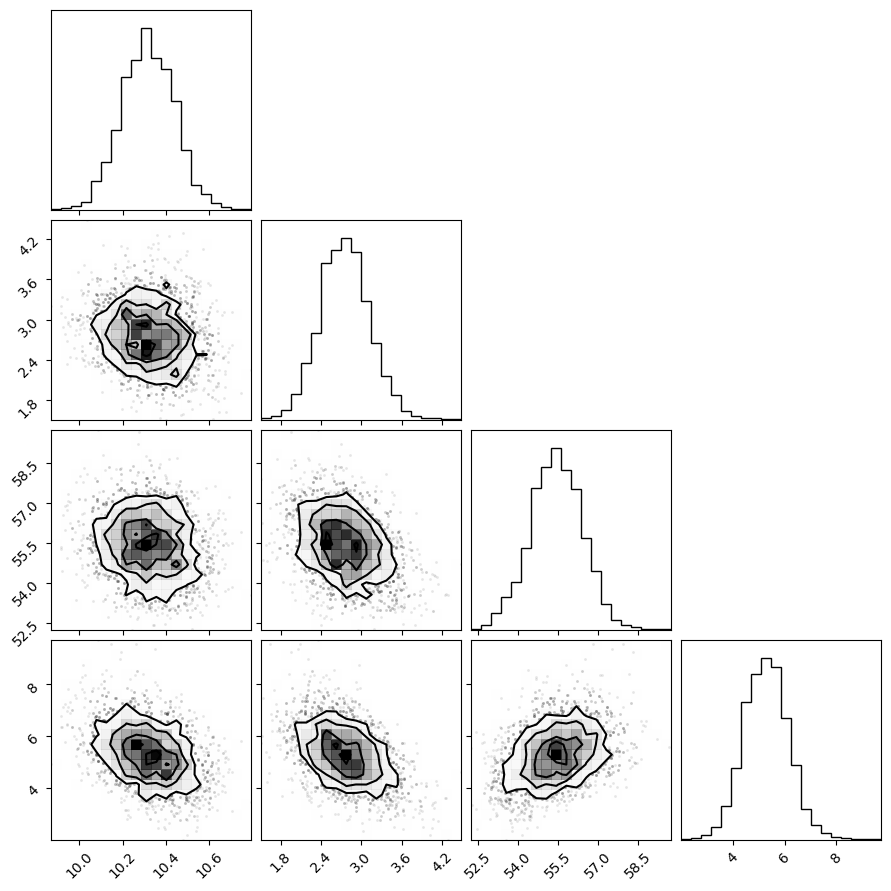

In [31]:
corner.corner(samples_equal2)

Text(0, 0.5, 'Flux')

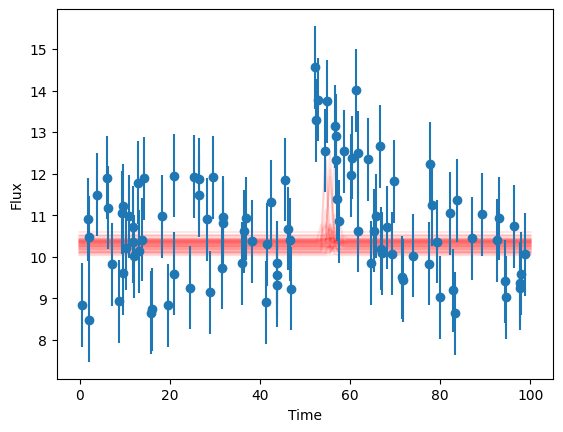

In [32]:
tgrid=np.linspace(0,100,100)

chosen_samples= samples_equal2[np.random.choice(len(samples_equal2),size=50)]

for chosen_params in chosen_samples:

    ygrid =  burst_model(chosen_params,tgrid)
    plt.plot(tgrid,ygrid,alpha=0.1,c='red')
    
plt.errorbar(t,y,yerr=y_err,fmt='o')
plt.xlabel("Time")
plt.ylabel("Flux")

Gaussian profile doesn't seem to fit very well.

### Odds ratio

Indeed odds ratio selects burst model

In [33]:
# adding errors
lnz1, lnz1err = sresults.logz[-1], sresults.logzerr[-1]
lnz2, lnz2err = sresults2.logz[-1], sresults2.logzerr[-1]

# Bayes factor
K = np.exp(lnz1 - lnz2)

# Error propagation
sigma_K = K * np.sqrt(lnz1err**2 + lnz2err**2)

print(f"Bayes Factor K: {K:.2f} ± {sigma_K:.2f}")

Bayes Factor K: 118.50 ± 52.02


In [34]:
def run_evidence(model, nlive, dlogz):
    sampler = dynesty.NestedSampler(
        log_likelihood,
        ptform,
        ndim,
        logl_args=[data, model],
        ptform_args=[model],
        nlive=nlive,
    )
    sampler.run_nested(dlogz=dlogz)
    return sampler.results

nlive_values = [200, 400, 800]
dlogz_values = [0.01, 0.001]

results = {}
for model in ['burst_model', 'gaussian_model']:
    for nlive in nlive_values:
        for dlogz in dlogz_values:
            res = run_evidence(model, nlive, dlogz)
            results[(model, nlive, dlogz)] = res
            print(
                f"{model:14s} nlive={nlive:<3d} dlogz={dlogz:<6} "
                f"lnZ={res.logz[-1]:.3f} ± {res.logzerr[-1]:.3f}"
            )

print("\nBayes factor for matched hyperparameter settings:")
lnK_values = []
lnK_errs = []
for nlive in nlive_values:
    for dlogz in dlogz_values:
        r_burst = results[('burst_model', nlive, dlogz)]
        r_gauss = results[('gaussian_model', nlive, dlogz)]
        lnK = r_burst.logz[-1] - r_gauss.logz[-1]
        lnK_err = np.sqrt(r_burst.logzerr[-1]**2 + r_gauss.logzerr[-1]**2)
        K = np.exp(lnK)
        K_err = K * lnK_err
        print(
            f"nlive={nlive:<3d} dlogz={dlogz:<6} "
            f"lnK={lnK:.3f} ± {lnK_err:.3f} "
            f"K={K:.2e} ± {K_err:.2e}"
        )
        lnK_values.append(lnK)
        lnK_errs.append(lnK_err)

lnK_mean = np.mean(lnK_values)
lnK_std = np.std(lnK_values, ddof=1)
lnK_int_err = np.mean(lnK_errs)
lnK_total_err = np.sqrt(lnK_std**2 + lnK_int_err**2)

print(
    "\nSummary across hyperparameters:\n"
    f"mean lnK = {lnK_mean:.3f}\n"
    f"scatter in lnK = {lnK_std:.3f}\n"
    f"mean integration error = {lnK_int_err:.3f}\n"
    f"combined lnK uncertainty = {lnK_total_err:.3f}\n"
    f"approximate K = {np.exp(lnK_mean):.2e} ± {np.exp(lnK_mean)*lnK_total_err:.2e}"
)

iter: 1276 | bound: 30 | nc: 1 | ncall: 13686 | eff(%):  9.323 | loglstar:   -inf < -87.438 <    inf | logz: -94.276 +/-  0.173 | dlogz: 34.414 >  0.010                                              c:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\dynesty\bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
iter: 1542 | bound: 98 | nc: 189 | ncall: 34642 | eff(%):  4.451 | loglstar:   -inf < -86.905 <    inf | logz: -93.361 +/-  0.169 | dlogz: 36.525 >  0.010                                            c:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\dynesty\bounding.py:707: UserWarning: The enlargement factor for 

burst_model    nlive=200 dlogz=0.01   lnZ=-63.103 ± 0.259


iter: 1569 | bound: 107 | nc: 131 | ncall: 36374 | eff(%):  4.314 | loglstar:   -inf < -86.948 <    inf | logz: -93.545 +/-  0.172 | dlogz: 34.166 >  0.001                                           c:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\dynesty\bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
iter: 1570 | bound: 108 | nc: 169 | ncall: 36543 | eff(%):  4.296 | loglstar:   -inf < -86.922 <    inf | logz: -93.543 +/-  0.172 | dlogz: 34.160 >  0.001                                           c:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\dynesty\bounding.py:707: UserWarning: The enlargement factor for 

burst_model    nlive=200 dlogz=0.001  lnZ=-63.180 ± 0.255


iter: 7683 | +400 | bound: 214 | nc: 1 | ncall: 129899 | eff(%):  6.242 | loglstar:   -inf < -48.755 <    inf | logz: -63.327 +/-  0.181 | dlogz:  0.000 >  0.010                                     

...

burst_model    nlive=800 dlogz=0.001  lnZ=-63.383 ± 0.128


iter: 1267 | bound: 35 | nc: 173 | ncall: 14156 | eff(%):  8.950 | loglstar:   -inf < -87.976 <    inf | logz: -95.215 +/-  0.180 | dlogz: 31.040 >  0.010                                            c:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\dynesty\bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
iter: 1605 | bound: 122 | nc: 32 | ncall: 47659 | eff(%):  3.368 | loglstar:   -inf < -86.796 <    inf | logz: -93.646 +/-  0.173 | dlogz: 32.344 >  0.010                                            c:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\dynesty\bounding.py:707: UserWarning: The enlargement factor for 

gaussian_model nlive=200 dlogz=0.01   lnZ=-68.179 ± 0.267


iter: 1593 | bound: 125 | nc: 65 | ncall: 62637 | eff(%):  2.543 | loglstar:   -inf < -86.785 <    inf | logz: -93.980 +/-  0.177 | dlogz: 32.359 >  0.001                                            c:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\dynesty\bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
iter: 1594 | bound: 126 | nc: 849 | ncall: 63486 | eff(%):  2.511 | loglstar:   -inf < -86.771 <    inf | logz: -93.978 +/-  0.177 | dlogz: 32.352 >  0.001                                           c:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\dynesty\bounding.py:707: UserWarning: The enlargement factor for 

KeyboardInterrupt: 